In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from nasch import TrafficCA_Periodic
from nasch_two_lane import TwoLaneNaSch

plt.rcParams.update({
    "figure.figsize":  (8, 5),
    "font.size":       12,
    "axes.grid":       True,
    "grid.alpha":      0.3,
    "axes.labelsize":  12,
    "axes.titlesize":  13,
    "legend.fontsize": 11,
    "savefig.dpi":     150,
    "savefig.bbox":    "tight",
})

DATA_DIR    = "../data"
FIGURES_DIR = "../figures"
os.makedirs(DATA_DIR,    exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)


Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen impor

Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._

Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importl

Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstra

Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<fr

# Two-lane NaSch — no-lights baseline

This notebook produces the two baseline figures for the two-lane
Nagel-Schreckenberg model. Both are the **no-lights** reference against
which the later lights experiments will be compared.

## Figure 1 — periodic fundamental diagram

Sweeps density over a range of lane-change probabilities `p_chg`. The
single-lane FD is overlaid so we can see how adding a second lane (and
varying `p_chg`) shifts the peak. This extends the single-lane
validation in `nagel_schreckenberg.ipynb` / `nasch_two_lane.ipynb` to
two lanes.

## Figure 2 — open-boundary throughput vs inflow

Sweeps inflow probability `p_in` for four values of `v_max` and two
values of `p_chg`. Overlays a `y = p_in` reference line so we can see
how far below ideal (per-lane) inflow the realised throughput sits —
the gap quantifies insertion-failure at the boundary. This is the
baseline against which the lights experiments' throughput curves will
be compared.

## Parameters

**Held fixed:** `v_max=5` for the FD, `p_rand=0.3`, `L=500`.

**Swept in FD:** `p_chg ∈ {0.0, 0.25, 0.5, 1.0}`, `rho ∈ [0.01, 0.99]`.

**Swept in open:** `v_max ∈ {1,2,3,5}`, `p_chg ∈ {0.0, 1.0}`,
`p_in ∈ [0.01, 1.0]`.

Both experiments use the two-phase warmup + measurement protocol from
CLAUDE.md. A first pass uses reduced counts (half-size) so figures
render same-day; rerun the sweep cells with `force=True` once the
half-size figures look right to produce the full-spec version.


In [2]:
def save_results(path, **arrays):
    """Save a dict of arrays (and 0-d scalars) to an .npz cache."""
    np.savez(path, **arrays)


def load_or_compute(path, compute_fn, force=False):
    """Load `path` if it exists; else compute, save, and return.

    Scalars stored via np.savez come back as 0-d ndarrays — use
    `result[key].item()` when formatting them into text.
    """
    if force or not os.path.exists(path):
        result = compute_fn()
        np.savez(path, **result)
        return result
    with np.load(path) as f:
        return {k: f[k] for k in f.files}


In [3]:
# Half-size first pass. Full spec in comments; rerun with force=True
# after editing to get publication-quality curves.
FD_V_MAX     = 5
FD_P_RAND    = 0.3
FD_L         = 500
FD_N_DENS    = 20     # full spec: 30
FD_T_WARMUP  = 1000   # full spec: 2000
FD_T_MEASURE = 2000   # full spec: 5000
FD_N_SEEDS   = 3      # full spec: 5
FD_P_CHG     = [0.0, 0.25, 0.5, 1.0]
FD_SEEDS     = np.arange(FD_N_SEEDS)


def compute_fd():
    densities = np.linspace(0.01, 0.99, FD_N_DENS)

    flows_single = np.zeros((FD_N_SEEDS, FD_N_DENS))
    flows_two    = np.zeros((len(FD_P_CHG), FD_N_SEEDS, FD_N_DENS))

    for si, s in enumerate(tqdm(FD_SEEDS, desc="single-lane FD")):
        for k, rho in enumerate(densities):
            np.random.seed(int(s) * 10_000 + k)
            n_cars = max(1, int(rho * FD_L))
            sim = TrafficCA_Periodic(L=FD_L, n_cars=n_cars,
                                     v_max=FD_V_MAX, p_rand=FD_P_RAND)
            for _ in range(FD_T_WARMUP):
                sim.step()
            J = 0.0
            for _ in range(FD_T_MEASURE):
                sim.step()
                J += sim.mean_flow()
            flows_single[si, k] = J / FD_T_MEASURE

    for pi, p_chg in enumerate(FD_P_CHG):
        for si, s in enumerate(tqdm(FD_SEEDS,
                desc=f"two-lane p_chg={p_chg}")):
            for k, rho in enumerate(densities):
                np.random.seed(int(s) * 10_000 + k)
                n_cars = max(1, int(rho * 2 * FD_L))
                sim = TwoLaneNaSch(
                    L=FD_L, n_lanes=2, v_max=FD_V_MAX,
                    p_rand=FD_P_RAND, p_chg=p_chg,
                    boundary="periodic", n_cars=n_cars,
                )
                for _ in range(FD_T_WARMUP):
                    sim.step()
                J = 0.0
                for _ in range(FD_T_MEASURE):
                    sim.step()
                    J += sim.mean_flow()
                flows_two[pi, si, k] = J / FD_T_MEASURE

    return dict(
        densities         = densities,
        flows_mean_single = flows_single.mean(axis=0),
        flows_std_single  = flows_single.std(axis=0),
        flows_mean_two    = flows_two.mean(axis=1),
        flows_std_two     = flows_two.std(axis=1),
        p_chg_values      = np.array(FD_P_CHG),
        v_max             = FD_V_MAX,
        p_rand            = FD_P_RAND,
        L                 = FD_L,
        seeds             = FD_SEEDS,
        T_warmup          = FD_T_WARMUP,
        T_measure         = FD_T_MEASURE,
        n_densities       = FD_N_DENS,
    )


fd = load_or_compute(f"{DATA_DIR}/two_lane_fd.npz", compute_fd)
print("FD arrays:", sorted(fd.keys()))


FD arrays: ['L', 'T_measure', 'T_warmup', 'densities', 'flows_mean_single', 'flows_mean_two', 'flows_std_single', 'flows_std_two', 'n_densities', 'p_chg_values', 'p_rand', 'seeds', 'v_max']


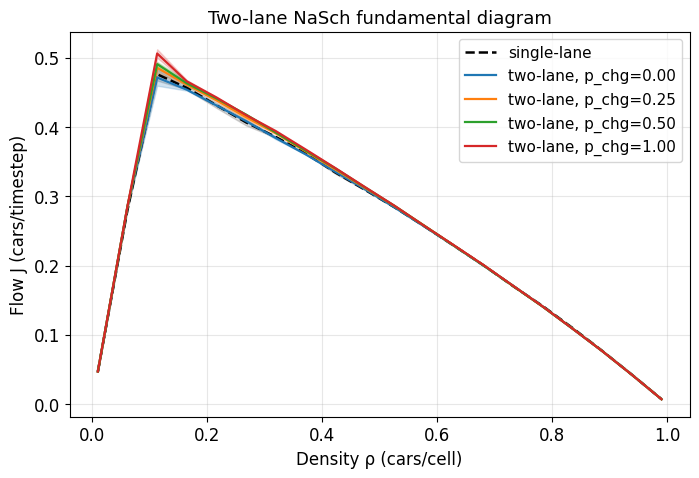

In [4]:
fig, ax = plt.subplots()

densities = fd["densities"]
mean_s    = fd["flows_mean_single"]
std_s     = fd["flows_std_single"]

ax.plot(densities, mean_s, "k--", linewidth=1.8, label="single-lane")
ax.fill_between(densities, mean_s - std_s, mean_s + std_s,
                color="k", alpha=0.15)

colours = plt.get_cmap("tab10").colors
for pi, p_chg in enumerate(fd["p_chg_values"]):
    mean_t = fd["flows_mean_two"][pi]
    std_t  = fd["flows_std_two"][pi]
    c = colours[pi % len(colours)]
    ax.plot(densities, mean_t, color=c, linewidth=1.6,
            label=f"two-lane, p_chg={float(p_chg):.2f}")
    ax.fill_between(densities, mean_t - std_t, mean_t + std_t,
                    color=c, alpha=0.2)

ax.set_xlabel("Density ρ (cars/cell)")
ax.set_ylabel("Flow J (cars/timestep)")
ax.set_title("Two-lane NaSch fundamental diagram")
ax.legend(loc="best")

fig.savefig(f"{FIGURES_DIR}/01_fd.png")
plt.show()


**Figure 1 — caption.** Two-lane NaSch fundamental diagram, periodic
boundaries. Parameters: `L = 500`, `n_densities = 20`,
`T_warmup = 1000`, `T_measure = 2000`, seeds `[0, 1, 2]`, `p_rand = 0.3`,
`v_max = 5`, `p_chg ∈ {0.00, 0.25, 0.50, 1.00}`. Solid curves and
shaded bands are mean ± std over seeds; dashed black is the single-lane
reference. Flow is measured in cars per timestep, normalised by
`n_lanes × L` so two-lane and single-lane sit on the same axis.


**Interpretation (predictions).**

- The `p_chg = 0` two-lane curve should coincide with the single-lane
  dashed curve: with no lane-changing, the two lanes are independent
  copies of the same system, and `TwoLaneNaSch.mean_flow` normalises
  by `n_lanes × L` exactly so this overlap is structural, not
  coincidental.
- Raising `p_chg` should lift the peak slightly and may nudge the
  critical density a little higher: cars escape small blockages by
  switching lanes, so the transition from free to jammed flow gives
  way more gradually.
- The jammed (high-density) branch should collapse onto a common curve
  regardless of `p_chg`, since once both lanes are congested the CWS
  rule's `gap_other_ahead > gap_own` condition almost always fails and
  lane-change becomes irrelevant.

*If the figure disagrees with any prediction, flag here for
investigation.*

-


In [5]:
# Half-size first pass. Full spec in comments.
OPEN_L         = 500
OPEN_P_RAND    = 0.3
OPEN_V_MAX     = [1, 2, 3, 5]
OPEN_P_CHG     = [0.0, 1.0]
OPEN_N_P_IN    = 25    # full spec: 40
OPEN_T_WARMUP  = 1000  # full spec: 2000
OPEN_T_MEASURE = 2000  # full spec: 5000
OPEN_N_SEEDS   = 3     # full spec: 5
OPEN_SEEDS     = np.arange(OPEN_N_SEEDS)


def compute_open():
    p_ins = np.linspace(0.01, 1.0, OPEN_N_P_IN)
    flows = np.zeros((len(OPEN_V_MAX), len(OPEN_P_CHG),
                      OPEN_N_SEEDS, OPEN_N_P_IN))

    for vi, v_max in enumerate(OPEN_V_MAX):
        for ci, p_chg in enumerate(OPEN_P_CHG):
            for si, s in enumerate(tqdm(OPEN_SEEDS,
                    desc=f"open v_max={v_max}, p_chg={p_chg}")):
                for k, p_in in enumerate(p_ins):
                    np.random.seed(int(s) * 10_000 + k)
                    sim = TwoLaneNaSch(
                        L=OPEN_L, n_lanes=2, v_max=v_max,
                        p_rand=OPEN_P_RAND, p_chg=p_chg,
                        boundary="open", p_in=float(p_in),
                    )
                    sim.warmup(OPEN_T_WARMUP)
                    flows[vi, ci, si, k] = sim.run(OPEN_T_MEASURE)

    return dict(
        p_ins        = p_ins,
        flows_mean   = flows.mean(axis=2),
        flows_std    = flows.std(axis=2),
        v_max_values = np.array(OPEN_V_MAX),
        p_chg_values = np.array(OPEN_P_CHG),
        L            = OPEN_L,
        p_rand       = OPEN_P_RAND,
        seeds        = OPEN_SEEDS,
        T_warmup     = OPEN_T_WARMUP,
        T_measure    = OPEN_T_MEASURE,
        n_p_in       = OPEN_N_P_IN,
    )


openb = load_or_compute(f"{DATA_DIR}/two_lane_open.npz", compute_open)
print("open arrays:", sorted(openb.keys()))


open v_max=1, p_chg=0.0:   0%|          | 0/3 [00:00<?, ?it/s]

open v_max=1, p_chg=1.0:   0%|          | 0/3 [00:00<?, ?it/s]

open v_max=2, p_chg=0.0:   0%|          | 0/3 [00:00<?, ?it/s]

open v_max=2, p_chg=1.0:   0%|          | 0/3 [00:00<?, ?it/s]

open v_max=3, p_chg=0.0:   0%|          | 0/3 [00:00<?, ?it/s]

open v_max=3, p_chg=1.0:   0%|          | 0/3 [00:00<?, ?it/s]

open v_max=5, p_chg=0.0:   0%|          | 0/3 [00:00<?, ?it/s]

open v_max=5, p_chg=1.0:   0%|          | 0/3 [00:00<?, ?it/s]

open arrays: ['L', 'T_measure', 'T_warmup', 'flows_mean', 'flows_std', 'n_p_in', 'p_chg_values', 'p_ins', 'p_rand', 'seeds', 'v_max_values']


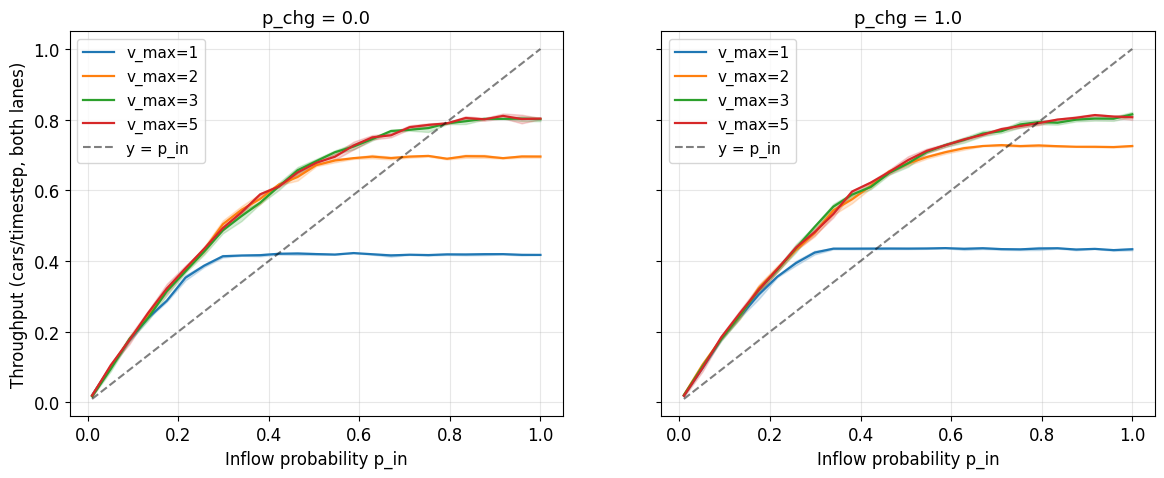

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

p_ins        = openb["p_ins"]
v_max_values = openb["v_max_values"]
p_chg_values = openb["p_chg_values"]
colours      = plt.get_cmap("tab10").colors

for ci in range(len(p_chg_values)):
    ax = axes[ci]
    for vi, v_max in enumerate(v_max_values):
        mean_t = openb["flows_mean"][vi, ci]
        std_t  = openb["flows_std"][vi, ci]
        c = colours[vi % len(colours)]
        ax.plot(p_ins, mean_t, color=c, linewidth=1.6,
                label=f"v_max={int(v_max)}")
        ax.fill_between(p_ins, mean_t - std_t, mean_t + std_t,
                        color=c, alpha=0.2)

    ax.plot(p_ins, p_ins, "k--", alpha=0.5, label="y = p_in")
    ax.set_xlabel("Inflow probability p_in")
    ax.set_title(f"p_chg = {float(p_chg_values[ci]):.1f}")
    ax.legend(loc="best")

axes[0].set_ylabel("Throughput (cars/timestep, both lanes)")

fig.savefig(f"{FIGURES_DIR}/01_open.png")
plt.show()


**Figure 2 — caption.** Two-lane NaSch open-boundary throughput vs
inflow probability. Parameters: `L = 500`, `n_p_in = 25`,
`T_warmup = 1000`, `T_measure = 2000`, seeds `[0, 1, 2]`,
`p_rand = 0.3`, `v_max ∈ {1, 2, 3, 5}`, `p_chg ∈ {0.0, 1.0}`. Left
panel: no lane-changing (equivalent to two independent single lanes).
Right panel: maximum lane-changing. Shaded bands are mean ± std over
seeds. Throughput is total cars exiting per timestep, summed over both
lanes. Dashed `y = p_in` is the per-lane ideal inflow; the gap between
each curve and this reference quantifies insertion failure at the
boundary.


**Interpretation (predictions).**

- At low `p_in` the road is in free flow; every injected car escapes,
  so throughput should follow `p_in` linearly up to ~`2 × p_in` (both
  lanes feeding independently).
- At high `p_in` throughput saturates at a `v_max`-dependent ceiling
  set by the braking rule and dawdling — this is the maximum
  sustainable flow of the open-boundary road, and higher `v_max` gives
  a higher ceiling.
- The `p_chg = 1` panel should sit **above** the `p_chg = 0` panel at
  moderate-to-high `p_in`: cars that would otherwise stall behind a
  slow car near the inflow region can switch lanes, easing the
  insertion bottleneck and lifting the ceiling.

*If the figure disagrees with any prediction, flag here for
investigation.*

-
